Question 1: Stereo

In [2]:
import numpy as np
from numpy.linalg import norm
from PIL import Image
import os
import matplotlib.pyplot as plt

In [21]:
def cost_ssd(patch1, patch2):
    """Compute the Sum of Squared Pixel Differences (SSD):

    Args:
        patch1: input patch 1 as (m, m) numpy array
        patch2: input patch 2 as (m, m) numpy array

    Returns:
        cost_ssd: the calcuated SSD cost as a floating point value
    """

    # START your code here
    # NOTE: You should remove the next line while coding
    difs = patch1 - patch2
    cost_ssd = np.sum(np.square(difs))
    # END your code here

    assert np.isscalar(cost_ssd)
    return cost_ssd


def cost_nc(patch1, patch2):
    """Compute the normalized correlation cost (NC):

    Args:
        patch1: input patch 1 as (m, m) numpy array
        patch2: input patch 2 as (m, m) numpy array

    Returns:
        cost_nc: the calculated NC cost as a floating point value
    """

    # START your code here
    # HINT: You can use the norm() function imported from numpy.linalg
    # NOTE: You should remove the next line while coding
    # norm can be used for denom once dif computed
    w1_flat = np.ndarray.flatten(patch1)
    w2_flat = np.ndarray.flatten(patch2)
    w1_bar, w2_bar = np.mean(w1_flat), np.mean(w2_flat)
    w1_dif, w2_dif = w1_flat-w1_bar, w2_flat-w2_bar
    cost_nc = np.dot(w1_dif/norm(w1_dif),w2_dif/norm(w2_dif))
    # END your code here

    assert np.isscalar(cost_nc)
    return cost_nc


def cost_function(patch1, patch2, alpha):
    """Compute the cost between two input window patches:
    Args:
        patch1: input patch 1 as (m, m) numpy array
        patch2: input patch 2 as (m, m) numpy array
        alpha: the weighting parameter for the cost function
    Returns:
        cost_val: the calculated cost value as a floating point value
    """
    assert patch1.shape == patch2.shape

    # START your code here
    # NOTE: You should remove the next line while coding
    m = patch1.shape[0]
    cost_val = 1/(m**2)*cost_ssd(patch1, patch2) + alpha*cost_nc(patch1, patch2)
    # END your code here

    assert np.isscalar(cost_val)
    return cost_val

def pad_image_RGB(input_img, window_size, padding_mode='symmetric'):
    r_pad = np.pad(array=input_img[:,:,0], pad_width=window_size//2, mode=padding_mode)
    g_pad = np.pad(array=input_img[:,:,1], pad_width=window_size//2, mode=padding_mode)
    b_pad = np.pad(array=input_img[:,:,2], pad_width=window_size//2, mode=padding_mode)
    padded_img = np.array([r_pad, g_pad, b_pad]).reshape(r_pad.shape[0],r_pad.shape[1],3)
    return padded_img

def pad_image(input_img, window_size, padding_mode='symmetric'):
    """Output the padded image

    Args:
        input_img: an input image as a numpy array
        window_size: the window size as a scalar value, odd number
        padding_mode: the type of padding scheme, among 'symmetric', 'reflect', or 'constant'

    Returns:
        padded_img: padded image as a numpy array of the same type as image
    """
    assert np.isscalar(window_size)
    assert window_size % 2 == 1

    # START your code here
    # HINT: You can use the np.pad() function with mode=padding_mode
    # NOTE: You should remove the next line while coding
    padded_img = np.pad(array=input_img, pad_width=window_size//2, mode=padding_mode)
    # END your code here

    return padded_img


def compute_disparity(padded_img_l, padded_img_r, max_disp, window_size, alpha):
    """Compute the disparity map by using the window-based matching:
    Args:
        padded_img_l: The padded left-view input image as 2-dimensional numpy array
        padded_img_r: The padded right-view input image as 2-dimensional numpy array
        max_disp: the maximum disparity as a search range
        window_size: the patch size for window-based matching, odd number
        alpha: the weighting parameter for the cost function
    Returns:
        disparity: numpy array (H,W) of the same size as the input image without padding
    """
    assert padded_img_l.ndim == 2
    assert padded_img_r.ndim == 2
    assert padded_img_l.shape == padded_img_r.shape
    assert max_disp > 0
    assert window_size % 2 == 1

    # START your code here
    # HINT: in numpy, there is a function named argmin
    # NOTE: You should remove the next line while coding
    disparity = np.zeros((padded_img_l.shape[0]-window_size+1, padded_img_l.shape[1]-window_size+1))
    for i in range(window_size//2,padded_img_l.shape[0]-window_size//2):
        for j in range(window_size//2,padded_img_l.shape[1]-window_size//2):
            # get patch 1
            patch1 = padded_img_l[i-window_size//2:i+window_size//2, j-window_size//2:j+window_size//2]
            cost_vals=[]
            # search along horizontal line
            left_index=np.max([i-max_disp, 0])
            for d in range(0,left_index+1):
                # generate patch 2
                patch2 = padded_img_r[i-window_size//2-d:i+window_size//2-d, j-window_size//2:j+window_size//2]
                # compute cost
                cost = cost_function(patch1, patch2, alpha)
                # keep list of cost values
                cost_vals.append(cost)
            # compute minimum cost and add to disparity map
            disp = np.min(cost_vals)
            disparity[i-window_size//2,j-window_size//2] = disp
    # END your code here

    assert disparity.ndim == 2
    return disparity


def compute_aepe(disparity_gt, disparity_res):
    """Compute the average end-point error of the estimated disparity map:

    Args:
        disparity_gt: the ground truth of disparity map as (H, W) numpy array
        disparity_res: the estimated disparity map as (H, W) numpy array

    Returns:
        aepe: the average end-point error as a floating point value
    """
    assert disparity_gt.ndim == 2 
    assert disparity_res.ndim == 2 
    assert disparity_gt.shape == disparity_res.shape

    # START your code here
    # NOTE: You should remove the next line while coding
    N = disparity_gt.shape[0]*disparity_gt.shape[1]
    aepe = (1/N)*np.sum(np.abs(disparity_gt-disparity_res))
    # END your code here

    assert np.isscalar(aepe)
    return aepe


def optimal_alpha():
    """Return alpha that leads to the smallest EPE
    (w.r.t. other values)"""

    # TODO: You need to fix the alpha value
    alpha = -0.06 #np.random.choice([-0.06, -0.01, 0.04, 0.1])
    return alpha


In [ ]:
print(os.getcwd())
ground_truth=Image.open(r'part1_gt.png').convert('L')
img_L = Image.open('part1_left.png').convert('L')
img_L = np.array(img_L)
img_R = Image.open('part1_right.png').convert('L')
img_R = np.array(img_R)

c:\Users\Sadie\Documents\GitHub\CPSC_425\A5\problem1_stereo


In [26]:
window=21
d=10 #????
L_pad = pad_image(input_img=img_L, window_size=window)
R_pad = pad_image(input_img=img_R, window_size=window)
disparity_map = compute_disparity(padded_img_l=L_pad, padded_img_r=R_pad,max_disp=d, window_size=window, alpha=-0.01)

C:\Users\Sadie\AppData\Local\Temp\ipykernel_16652\2980693242.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(disparity_map)


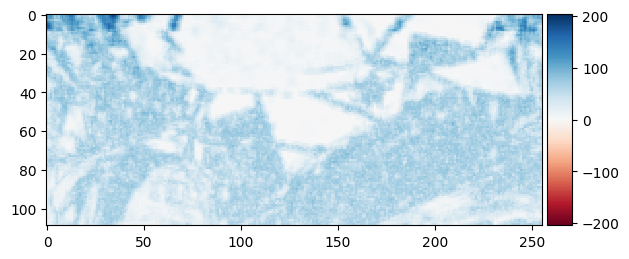

In [25]:
import skimage.io as skio
skio.imshow(disparity_map)